# Spotify Track Popularity — EDA & Prediction

**Can a track's *audio features alone* predict how popular it will be?**

- **Dataset:** `spotify_songs.csv` — ~32,000 tracks from the *30,000 Spotify Songs* dataset
  (TidyTuesday 2020-01-21, via the `spotifyr` package). See `data/dataset_readme.md` for full
  attribution and the data dictionary.
- **Target:** `track_popularity` (0-100).
- **Approach:** exploratory analysis of artists, genres and audio features, then a comparison
  of regression models (linear → tree ensembles → gradient boosting) with feature-importance
  analysis.
- **Headline result:** audio features explain only a limited share of popularity
  (**best R² ≈ 0.30**, Random Forest) — an *honest* result that reflects a real ceiling:
  popularity is driven heavily by factors absent from the data (marketing, playlisting,
  artist fame).


## 1. Setup and data load

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/spotify_songs.csv")
print("shape:", df.shape)
df.head()

shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [2]:
audio_cols = ['track_popularity','danceability','energy','key','loudness','mode',
              'speechiness','acousticness','instrumentalness','liveness','valence',
              'tempo','duration_ms']
df.describe()[audio_cols].round(2)

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00
mean,42.48,0.65,0.70,5.37,-6.72,0.57,0.11,0.18,0.08,0.19,0.51,120.88,225799.81
std,24.98,0.15,0.18,3.61,2.99,0.50,0.10,0.22,0.22,0.15,0.23,26.90,59834.01
min,0.00,0.00,0.00,0.00,-46.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4000.00
25%,24.00,0.56,0.58,2.00,-8.17,0.00,0.04,0.02,0.00,0.09,0.33,99.96,187819.00
50%,45.00,0.67,0.72,6.00,-6.17,1.00,0.06,0.08,0.00,0.13,0.51,121.98,216000.00
75%,62.00,0.76,0.84,9.00,-4.64,1.00,0.13,0.26,0.00,0.25,0.69,133.92,253585.00
max,100.00,0.98,1.00,11.00,1.27,1.00,0.92,0.99,0.99,1.00,0.99,239.44,517810.00


## 2. Artist exploration — Bayesian weighted popularity

A naive "top artists by average popularity" ranking is dominated by artists with only one or
two tracks. A **Bayesian weighted average** shrinks small-sample artists toward the global mean,
giving a more trustworthy ranking (`m` = strength of the prior).

In [3]:
print("unique artists:", df["track_artist"].nunique())

unique artists: 10692


In [4]:
global_mean = df["track_popularity"].mean()
m = 10  # prior strength: bigger => stronger penalty for low-track-count artists

artist_stats = df.groupby("track_artist").agg(
    avg_pop=("track_popularity", "mean"),
    count=("track_popularity", "size"),
)
artist_stats["weighted_score"] = (
    (artist_stats["count"] * artist_stats["avg_pop"] + m * global_mean)
    / (artist_stats["count"] + m)
)
artist_stats.sort_values("weighted_score", ascending=False).head(15)

,avg_pop,count,weighted_score
track_artist,,,
Billie Eilish,83.581395,43,75.825864
Travis Scott,82.147059,34,73.131155
Harry Styles,83.592593,27,72.480292
Roddy Ricch,88.210526,19,72.440373
Lewis Capaldi,83.714286,21,70.411962
Khalid,75.298246,57,70.399564
Ed Sheeran,74.231884,69,70.212289
Camila Cabello,77.105263,38,69.891059
DaBaby,87.857143,14,68.948784


## 3. Genre & subgenre analysis

In [5]:
df["playlist_genre"].value_counts()

playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

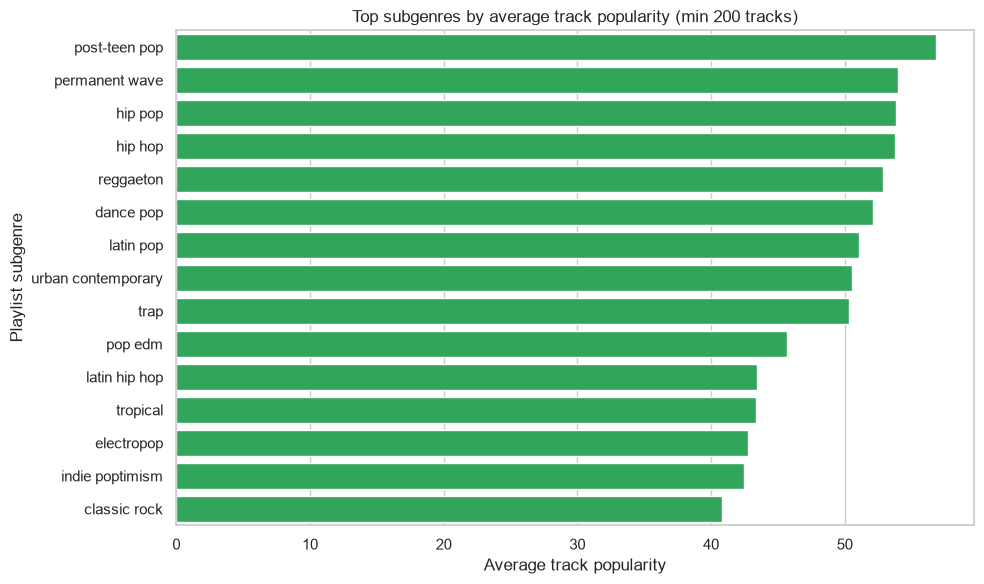

In [6]:
sub_stats = (df.groupby("playlist_subgenre")
             .agg(avg_pop=("track_popularity", "mean"), count=("track_popularity", "size"))
             .sort_values("avg_pop", ascending=False))
top_sub = sub_stats[sub_stats["count"] >= 200].head(15).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_sub, x="avg_pop", y="playlist_subgenre", color="#1DB954")
plt.title("Top subgenres by average track popularity (min 200 tracks)")
plt.xlabel("Average track popularity"); plt.ylabel("Playlist subgenre")
plt.tight_layout(); plt.show()

## 4. Audio-feature relationships

Correlation between audio features and popularity. The immediate takeaway: **no single audio feature correlates strongly with popularity** — the largest absolute correlations are modest, which foreshadows the modelling ceiling.

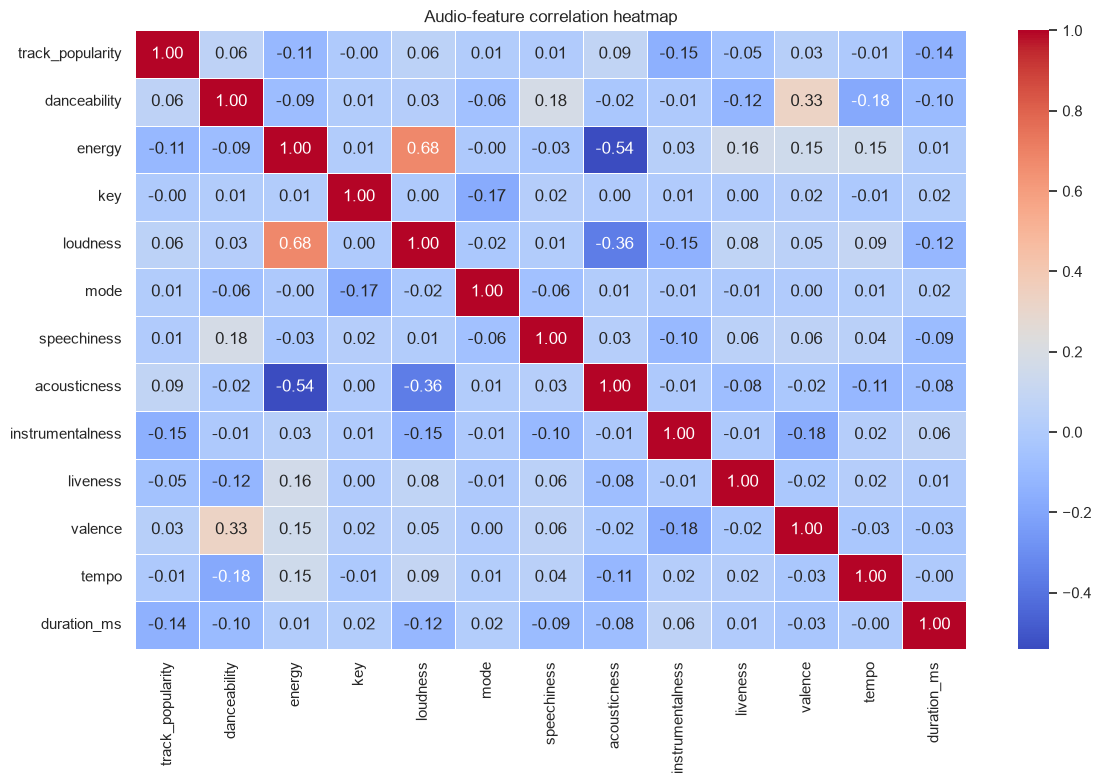

In [7]:
corr = df[audio_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Audio-feature correlation heatmap")
plt.tight_layout(); plt.show()

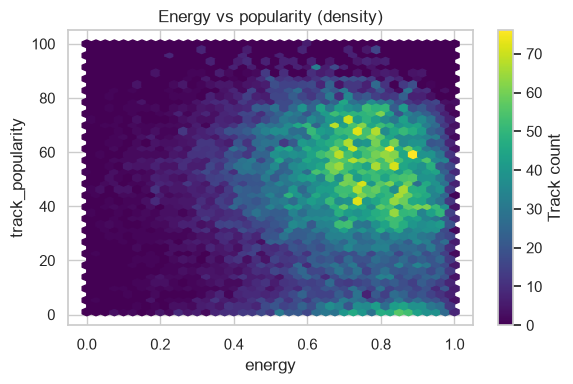

In [8]:
df_nozero = df[df["track_popularity"] > 0]
plt.figure(figsize=(6, 4))
plt.hexbin(df_nozero["energy"], df_nozero["track_popularity"], gridsize=40, cmap="viridis")
plt.colorbar(label="Track count")
plt.xlabel("energy"); plt.ylabel("track_popularity")
plt.title("Energy vs popularity (density)")
plt.tight_layout(); plt.show()

## 5. Predictive modelling

We predict `track_popularity` from the 12 numeric audio features and compare models from a
simple linear baseline through to tree ensembles and gradient boosting, scored on a held-out
20% test set (MAE, RMSE, R²).

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

num_features = ["danceability","energy","loudness","speechiness","acousticness",
                "instrumentalness","liveness","valence","tempo","duration_ms","key","mode"]

X = df[num_features]
y = df["track_popularity"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, "test:", X_test.shape)

train: (26266, 12) test: (6567, 12)


In [10]:
def evaluate_regression(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "model": name,
        "MAE": round(mean_absolute_error(y_test, preds), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 3),
        "R2": round(r2_score(y_test, preds), 3),
    }

results = []
results.append(evaluate_regression("Linear Regression", LinearRegression()))
results.append(evaluate_regression("Ridge", Ridge(alpha=1.0)))
results.append(evaluate_regression("Random Forest", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)))
results.append(evaluate_regression("Gradient Boosting", GradientBoostingRegressor(n_estimators=400, learning_rate=0.05, max_depth=3, random_state=42)))

try:
    from xgboost import XGBRegressor
    results.append(evaluate_regression("XGBoost", XGBRegressor(
        n_estimators=800, learning_rate=0.03, max_depth=6,
        subsample=0.85, colsample_bytree=0.85, random_state=42)))
except Exception as e:
    print("XGBoost not available:", e)

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,model,MAE,RMSE,R2
0,Random Forest,16.331,20.823,0.302
1,XGBoost,18.316,22.133,0.211
2,Gradient Boosting,19.473,23.386,0.119
3,Linear Regression,20.085,24.021,0.071
4,Ridge,20.085,24.021,0.071


**Random Forest is the strongest model (R² ≈ 0.30, MAE ≈ 16 popularity points).**
Linear models capture almost nothing (R² ≈ 0.07), confirming the relationship is weak and
non-linear. Gradient boosting and XGBoost land in between at these settings.

## 6. Feature importance

Two views of what the Random Forest relies on: impurity-based importance, and **permutation importance** on the test set (more reliable, as it measures the actual drop in test performance when a feature is shuffled).

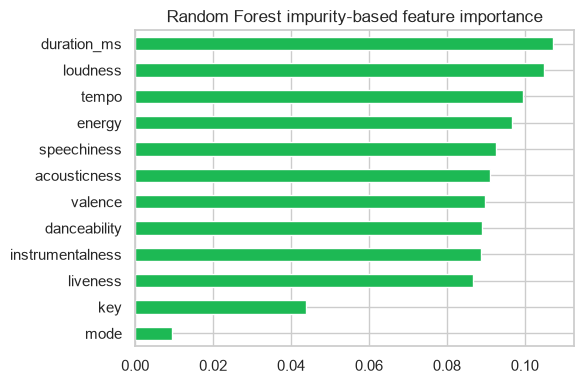

In [11]:
rf = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=num_features).sort_values()
importances.plot(kind="barh", figsize=(6, 4), color="#1DB954")
plt.title("Random Forest impurity-based feature importance")
plt.tight_layout(); plt.show()

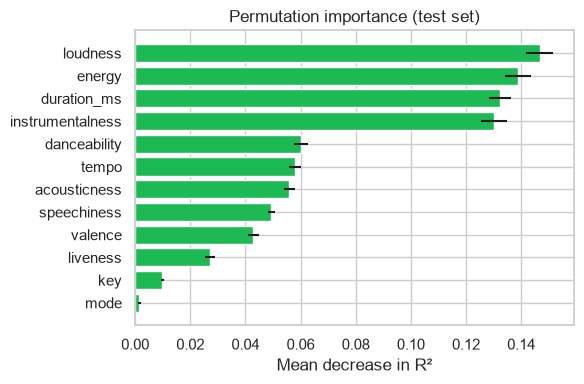

,feature,importance_mean,importance_std
0,loudness,0.146664,0.004908
1,energy,0.138821,0.004792
2,duration_ms,0.132294,0.003839
3,instrumentalness,0.130092,0.004612
4,danceability,0.060127,0.002450
5,tempo,0.057857,0.002184
6,acousticness,0.055850,0.002021
7,speechiness,0.049410,0.001374
8,valence,0.042894,0.002038
9,liveness,0.027065,0.001903


In [12]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = (pd.DataFrame({"feature": X_test.columns,
                         "importance_mean": perm.importances_mean,
                         "importance_std": perm.importances_std})
           .sort_values("importance_mean", ascending=False).reset_index(drop=True))

plt.figure(figsize=(6, 4))
plt.barh(perm_df["feature"][::-1], perm_df["importance_mean"][::-1],
         xerr=perm_df["importance_std"][::-1], color="#1DB954")
plt.title("Permutation importance (test set)")
plt.xlabel("Mean decrease in R²")
plt.tight_layout(); plt.show()
perm_df

## 7. Findings and limitations

**Findings**
- **loudness, energy, duration and instrumentalness** are the most informative audio features
  (consistent across impurity- and permutation-based importance).
- Non-linear ensembles massively outperform linear models (R² 0.30 vs 0.07), so what signal
  exists is non-linear.
- Even the best model explains only **~30% of the variance** in popularity.

**Limitations**
- Spotify popularity is driven heavily by factors **not in this dataset**: marketing, playlist
  placement, release timing, and artist fame. Audio features alone therefore have a natural
  predictive ceiling — the honest R² ≈ 0.30 reflects that, and is the real finding.
- `track_popularity` is a snapshot; it changes over time.
- No hyperparameter search beyond a few manual settings.
